# Network Science Assignment 3

Author:  
Elias Müller   
18-615-658

Submission Date:  
Monday, 14. October 2024

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import networkx as nx
from scipy.stats import pearsonr, spearmanr, kendalltau
import glob

First the necessary data is imported structured into a data list and a naming list for accessibility

In [2]:
data_paths = glob.glob("data/*.gml")
data_names = [str(x.replace("data/graph_", "")).replace(".gml", "") for x in data_paths]
data_lst = list(map(nx.read_gml, data_paths))

The below functions serve as helpers in this assignment reducing overall boilerplate code.

In [3]:
# initialize a flattened figure
def initialize_figure(COLS, ROWS):
    fig, axes = plt.subplots(ROWS, COLS, figsize=(5 * COLS, 5 * ROWS))
    axes = axes.flatten() 

    return fig, axes

# set the labels and the title of a given subplot ax
def set_ax_labels(ax, x_label, y_label, title):
    ax.set_xlabel(f"{x_label}")
    ax.set_ylabel(f"{y_label}")
    ax.set_title(f" {title}")

## Task 1
Compute degree, closeness, betweenness and eigenvector centrality for each node. Plot the distribution for each of the centralities, paying attention to binning.

### Comments
- **Centrality Computation**: For each dataset, we calculate the following centrality measures using NetworkX:
  - **Degree Centrality**
  - **Closeness Centrality**
  - **Betweenness Centrality**
  - **Eigenvector Centrality**

- **Plotting**:
  - **`plot_dist`**: This function takes a list of centrality values and generates a histogram. It uses logarithmic binning and sets `density=True` to compute the pdf. Both axes are displayed on a logarithmic scale.
  
  - **`plot_centrality`**: A helper method designed to compute and format the desired centrality measures for a given NetworkX graph. It filters out zero values, particularly for measures like betweenness centrality, forgoing issues of plotting zeros on logarithmic axes. To retain the information, if filtering is used, the removed portion is annotated on the respective graph.
  
  - **`plot_degree_centrality`**, **`plot_closeness_centrality`**, **`plot_betweenness_centrality`**, and **`plot_eigenvector_centrality`** call `plot_centrality` with their respective centrality functions.


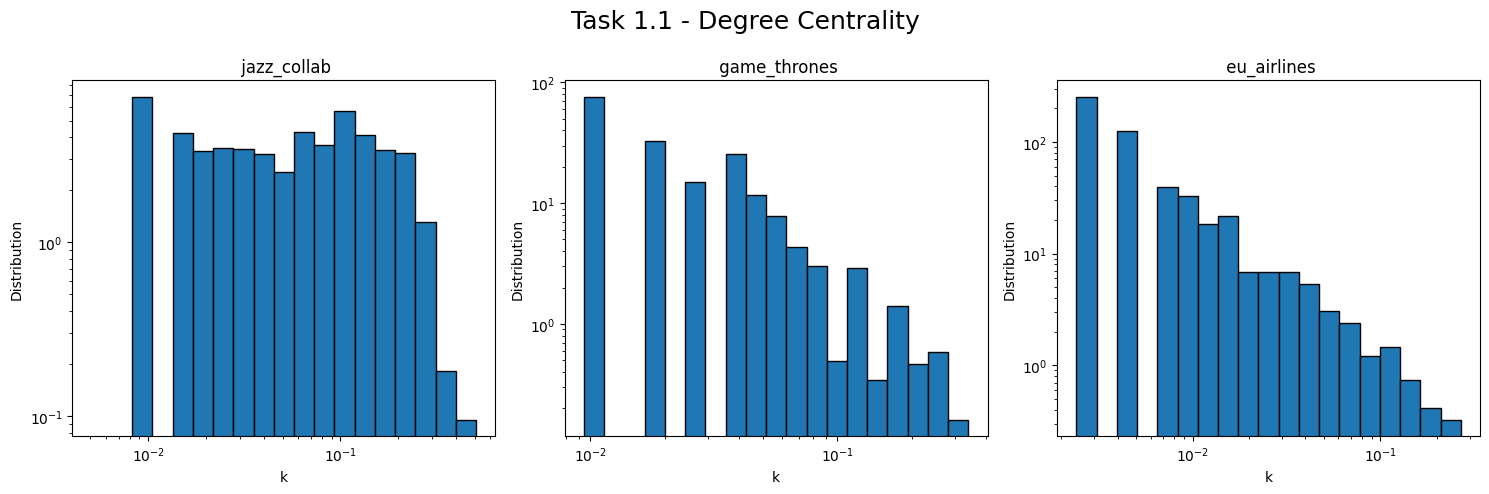

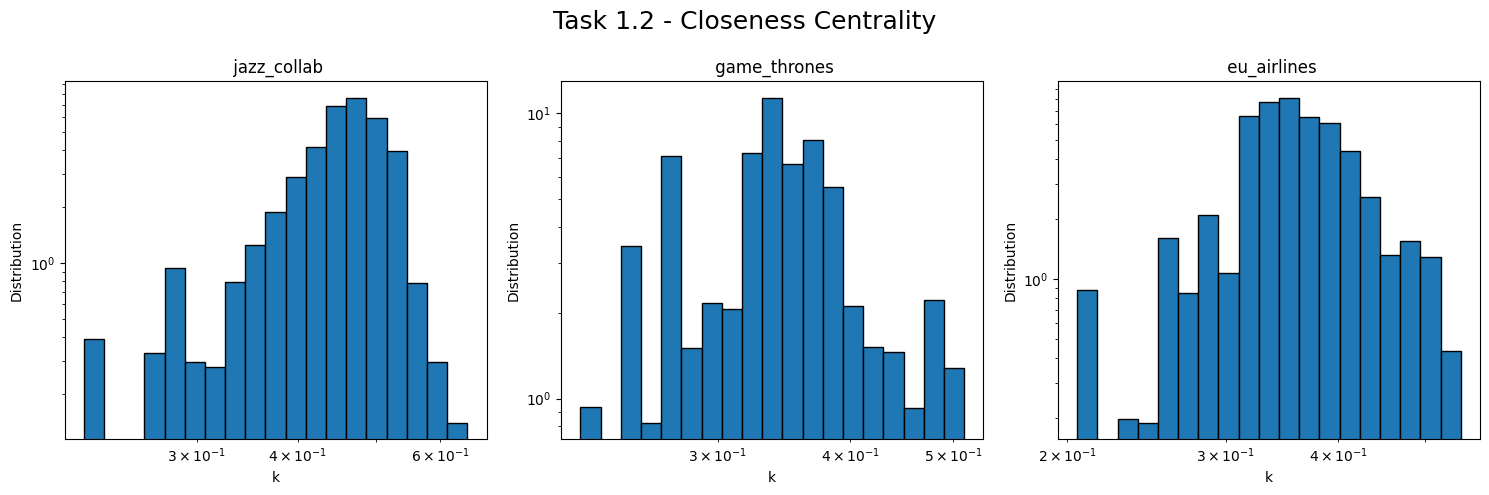

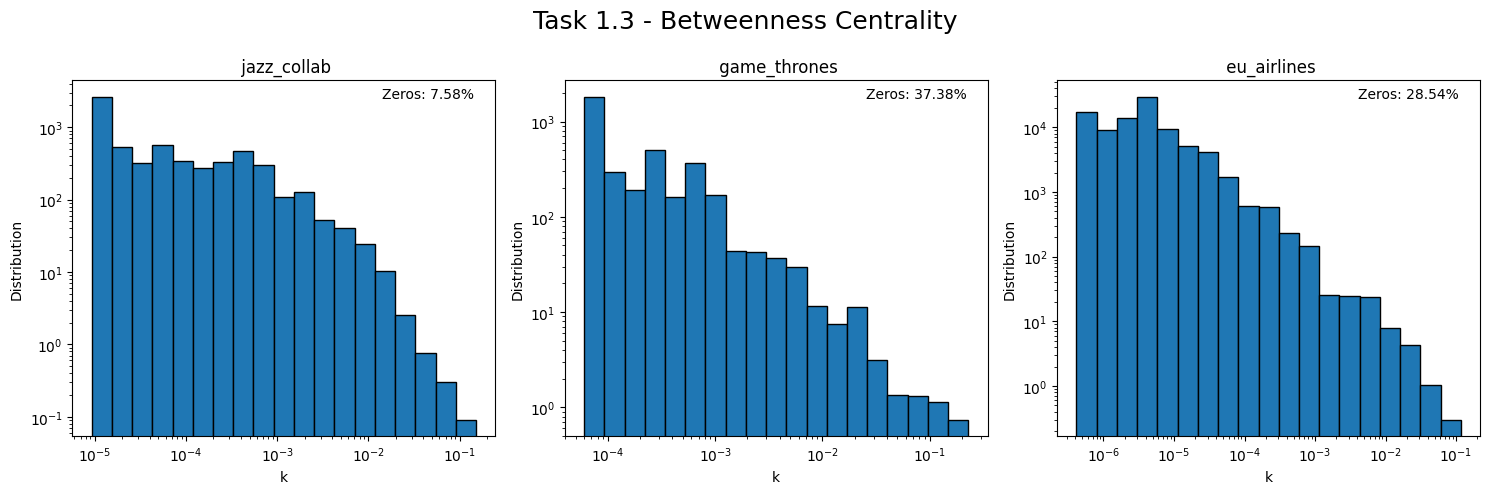

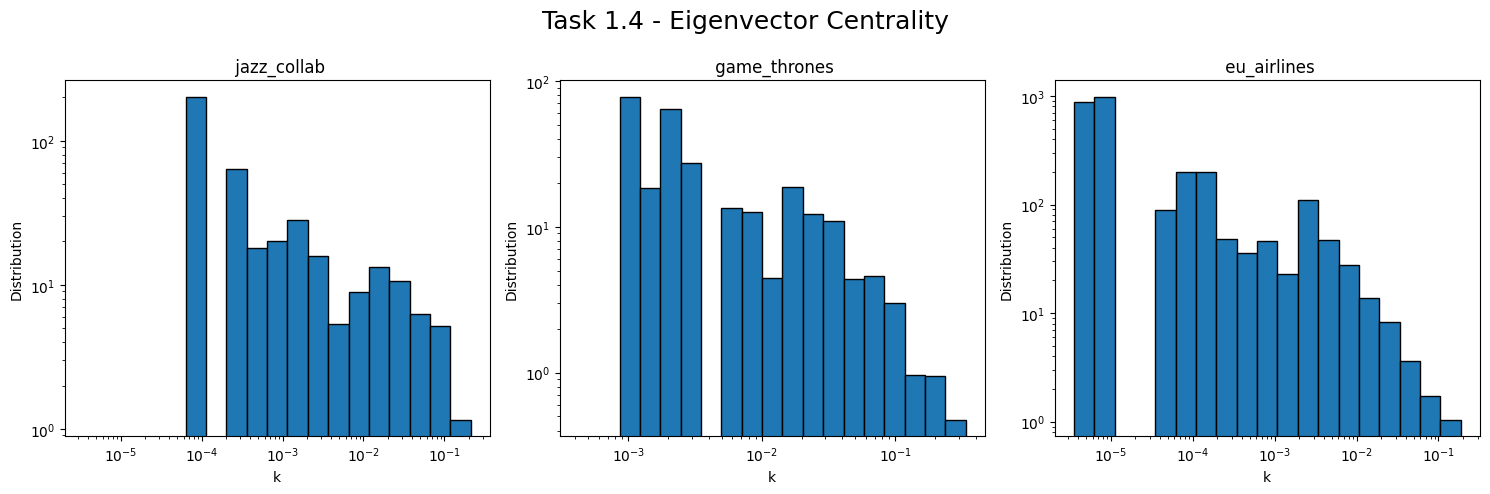

In [4]:
# plotting and annotations
def plot_dist(centrality, ax, title, filter_zero = False):
    bins = np.logspace(np.log10(min(centrality)), np.log10(max(centrality)), 20)

    ax.hist(centrality, bins=bins, density=True, edgecolor='black') 
    ax.set_xscale('log')
    ax.set_yscale('log')
    set_ax_labels(ax, "k", "Distribution", f"{title}")
    if filter_zero: 
        ax.annotate(f'Zeros: {filter_zero:.2f}%', xy=(0.95, 0.95), xycoords='axes fraction', fontsize=10, horizontalalignment='right')

# get centralities given an nx function and an nx graph G
def plot_centrality(G, centrality_func, ax, title, filter_zero=False):
    centrality = list(centrality_func(G).values())
    
    if filter_zero:
        filtered = len(centrality)
        centrality = [c for c in centrality if c > 0]
        filtered = (1-(len(centrality)/(filtered)))*100
        plot_dist(centrality, ax, title, filtered)
        return
    
    plot_dist(centrality, ax, title)

# individual centralities
def plot_degree_centrality(G, ax, title):
    plot_centrality(G, nx.degree_centrality, ax, title)

def plot_closeness_centrality(G, ax, title):
    plot_centrality(G, nx.closeness_centrality, ax, title)

def plot_betweenness_centrality(G, ax, title):
    plot_centrality(G, nx.betweenness_centrality, ax, title, filter_zero=True)

def plot_eigenvector_centrality(G, ax, title):
    plot_centrality(G, nx.eigenvector_centrality, ax, title)

# main function for Task 1, iterating over all data
def main_degree_centrality(data_list, centrality, title):
    fig, axes = initialize_figure(3,1)
    for i, G in enumerate(data_list):
        centrality(G, axes[i], title=data_names[i])
        
    fig.suptitle(f"{title}", fontsize=18)

    plt.tight_layout(rect=[0, 0, 1, 0.99]) 
    plt.show()

# helper struct
plot_func_title_pairs = [
    (plot_degree_centrality, "Task 1.1 - Degree Centrality"),
    (plot_closeness_centrality, "Task 1.2 - Closeness Centrality"),
    (plot_betweenness_centrality, "Task 1.3 - Betweenness Centrality"),
    (plot_eigenvector_centrality, "Task 1.4 - Eigenvector Centrality")
]

#main loop
for (func, title) in plot_func_title_pairs:
    main_degree_centrality(data_lst, func, title)


## Task 2

Do a scatter plot of each pair of centralities (6 plots total). Compute the Pearson, Spearman and Kendall correlation coefficient for each pair and note them on the scatter plots.


### Comments
- **Centrality Computation**: The function `compute_centralities(G)` calculates the following centrality measures for a given NetworkX graph:
  - **Degree Centrality**
  - **Betweenness Centrality**
  - **Closeness Centrality**
  - **Eigenvector Centrality**

- **Scatter Plot with Correlations**
  - The function `scatter_with_correlations(x, y, xlabel, ylabel, ax)` creates scatter plots for pairs of centrality measures:
  - Computes and annotates the Pearson, Spearman, and Kendall correlation coefficients on the plot
  
- **Plotting Centrality Correlations**
  - The `plot_centrality_correlations(G, name)` function generates scatter plots for specified pairs of centrality measures.
    - `compute_centralities` returns the centrality values.
    - Creates a grid of scatter plots for the given pairs of centralities given in the helper struct `centrality_paris`.

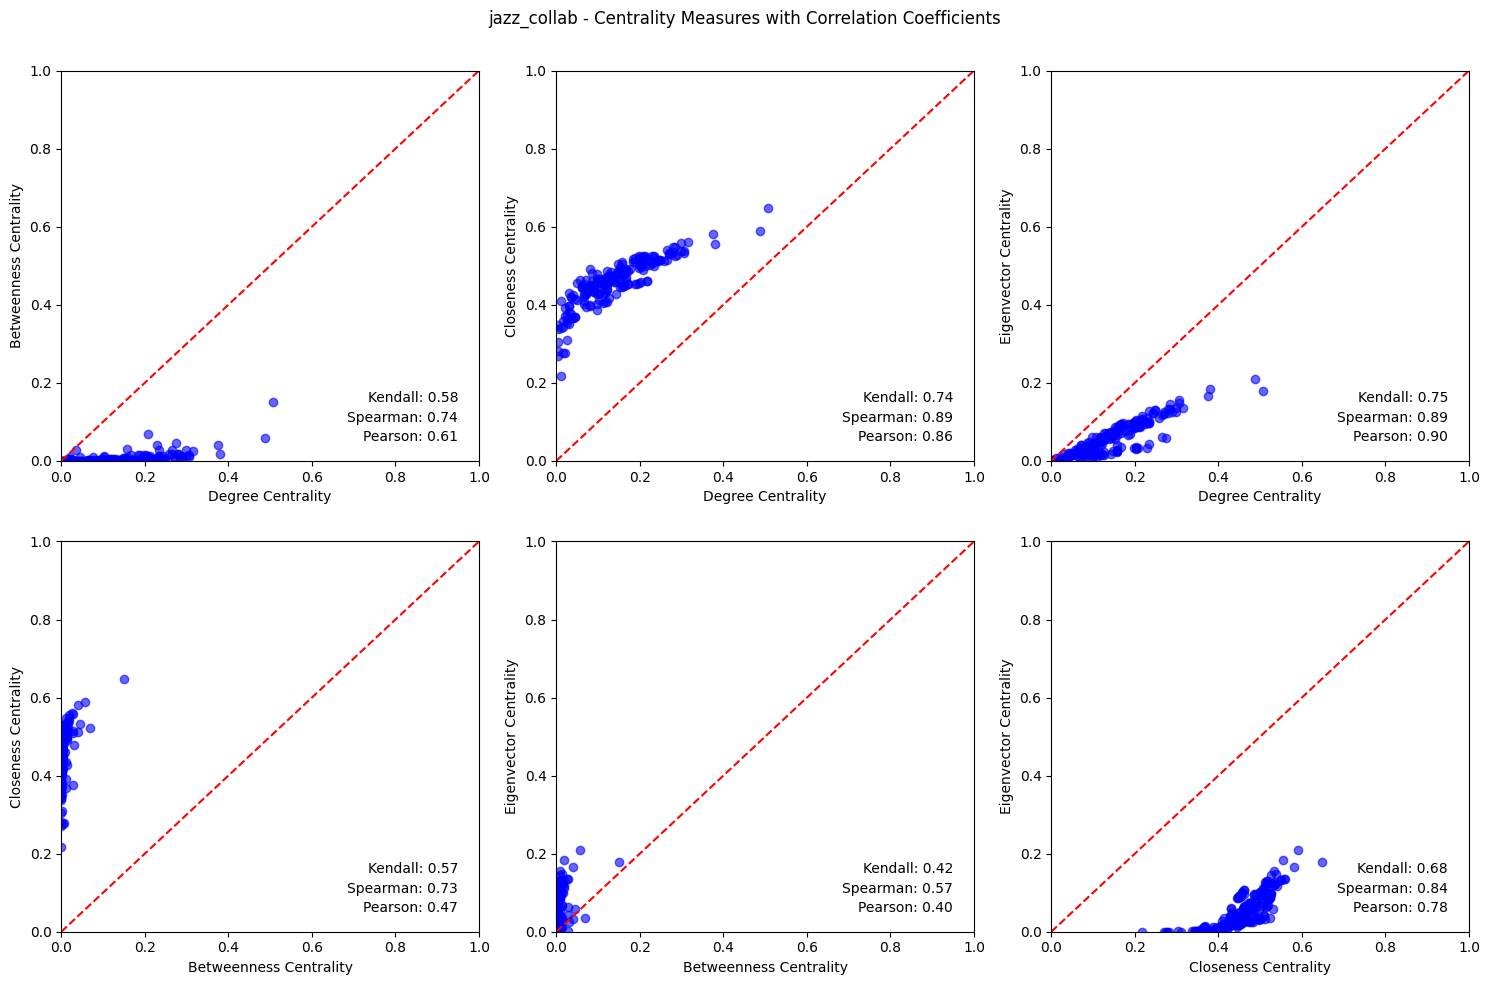

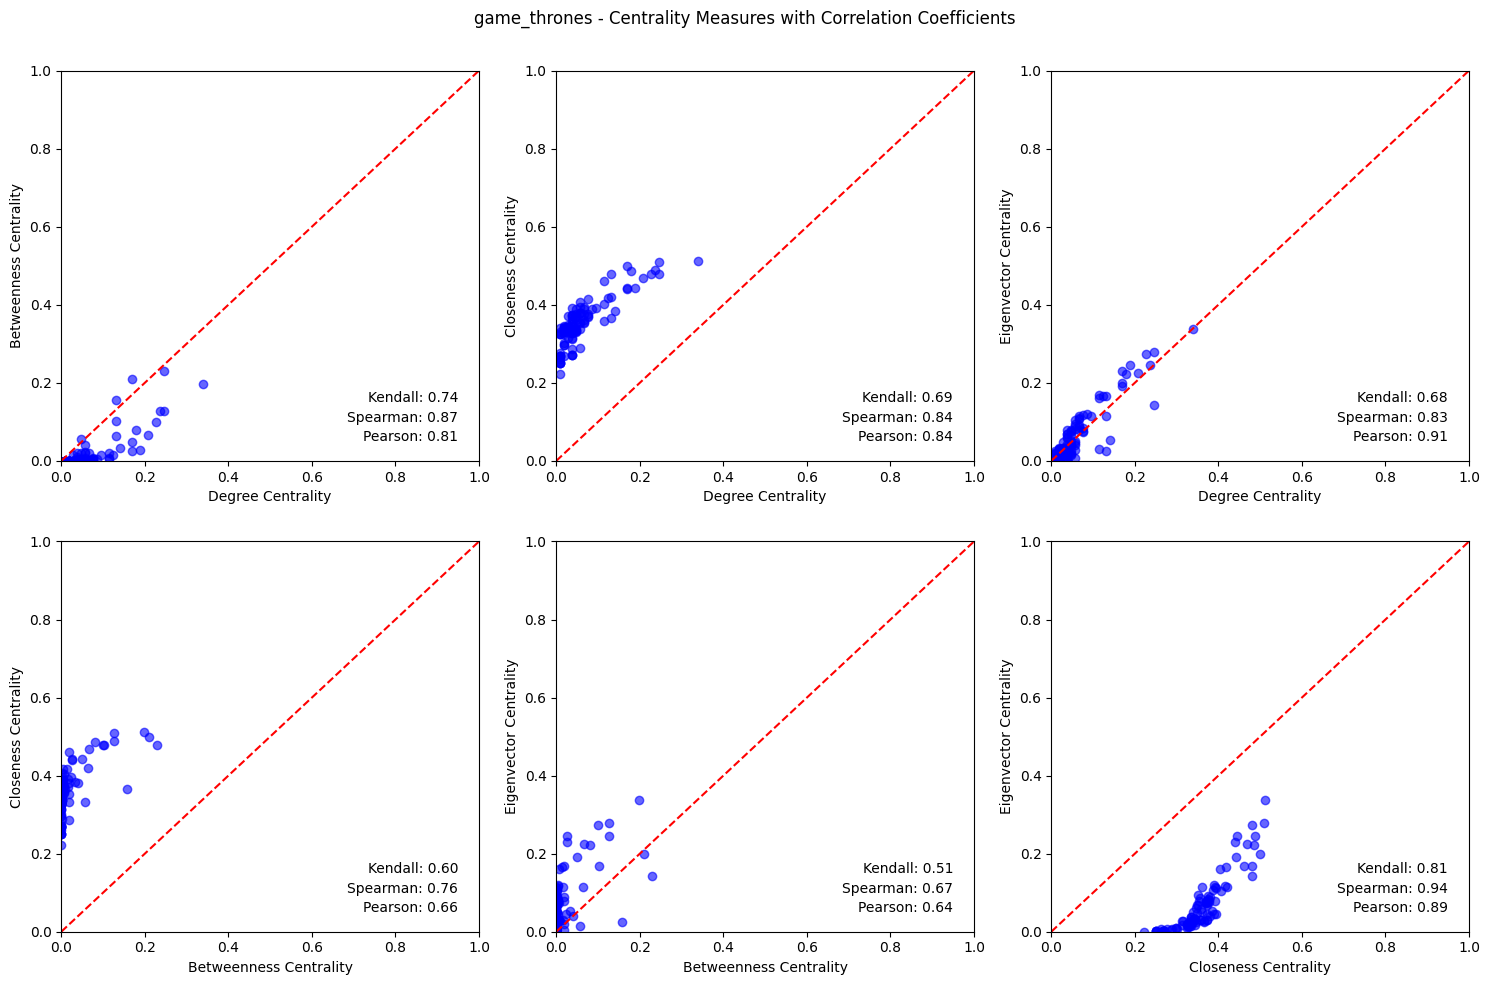

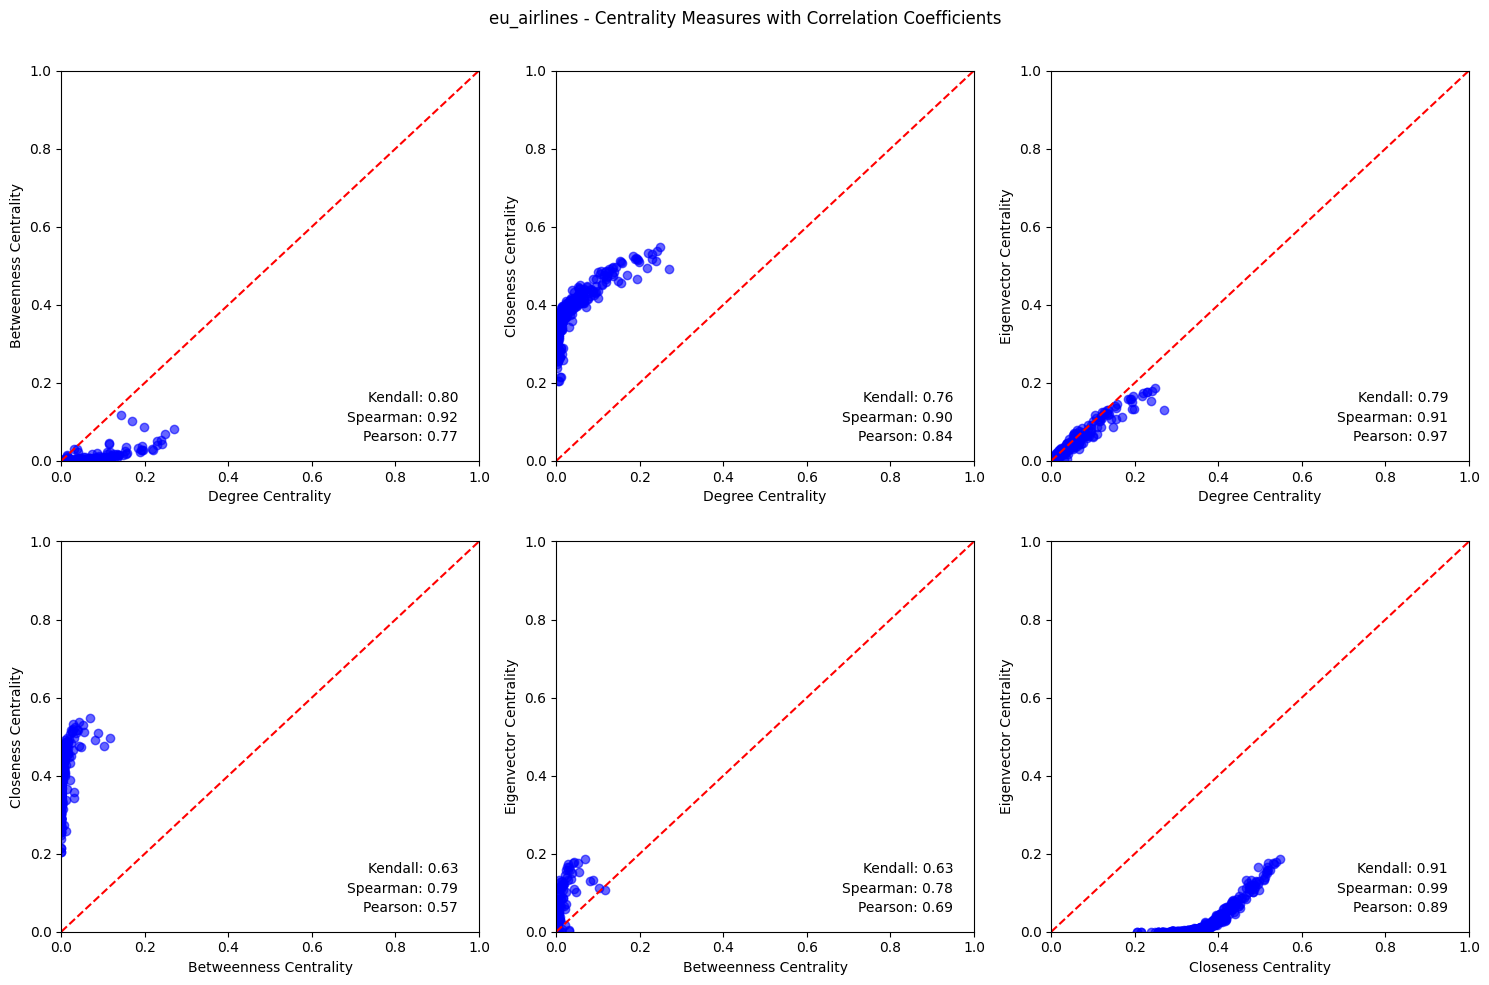

In [5]:
# centralities
def compute_centralities(G):
    degree = list(nx.degree_centrality(G).values())
    betweenness = list(nx.betweenness_centrality(G).values())
    closeness = list(nx.closeness_centrality(G).values())
    eigenvector = list(nx.eigenvector_centrality(G).values())

    return degree, betweenness, closeness, eigenvector

# Scatter plot per pair
def scatter_with_correlations(x, y, xlabel, ylabel, ax):
    ax.scatter(x, y, alpha=0.6, color="b")
    set_ax_labels(ax, xlabel, ylabel, '')

    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    ax.plot([0, 1], [0, 1], color='red', linestyle='--')

    # coeffs
    pearson_corr, _ = pearsonr(x, y)
    spearman_corr, _ = spearmanr(x, y)
    kendall_corr, _ = kendalltau(x, y)

    # Annotate figure with coeffs
    ax.annotate(f'Pearson: {pearson_corr:.2f}', xy=(0.95, 0.05), xycoords='axes fraction', fontsize=10, horizontalalignment='right')
    ax.annotate(f'Spearman: {spearman_corr:.2f}', xy=(0.95, 0.10), xycoords='axes fraction', fontsize=10, horizontalalignment='right')
    ax.annotate(f'Kendall: {kendall_corr:.2f}', xy=(0.95, 0.15), xycoords='axes fraction', fontsize=10, horizontalalignment='right')


def plot_centrality_correlations(G, name):
    degree, betweenness, closeness, eigenvector = compute_centralities(G)
    fig, axes = initialize_figure(3,2)
 
    # correlation pair + axis labels
    centrality_pairs = [
        (degree, betweenness, 'Degree Centrality', 'Betweenness Centrality'),
        (degree, closeness, 'Degree Centrality', 'Closeness Centrality'),
        (degree, eigenvector, 'Degree Centrality', 'Eigenvector Centrality'),
        (betweenness, closeness, 'Betweenness Centrality', 'Closeness Centrality'),
        (betweenness, eigenvector, 'Betweenness Centrality', 'Eigenvector Centrality'),
        (closeness, eigenvector, 'Closeness Centrality', 'Eigenvector Centrality')
    ]

    for ax, (x, y, xlabel, ylabel) in zip(axes, centrality_pairs):
        scatter_with_correlations(x, y, xlabel, ylabel, ax)

    fig.suptitle(f"{name} - Centrality Measures with Correlation Coefficients")
    plt.tight_layout(rect=[0, 0, 1, 0.99])

for i, g in enumerate(data_lst):
    plot_centrality_correlations(g, data_names[i])


## Task 3

Randomise the given networks and calculate the same centralities as in 1. Create a scatter plot of the original centralities and the randomised ones compute the Pearson correlation coefficient for each air and note them on the scatter plot. Briefly comment on what you have observed. 

### Comments
- **Scatter Plot with Correlations**
  - The function `scatter_with_correlations(x, y, xlabel, ylabel, title, ax)` generates scatter plots for pairs of centrality measures from original and randomized graphs. Further it computes the Pearson correlation coefficient and annotates the plot.

- **Plotting Centrality Correlations**
  - The `plot_centrality_correlations(G, name)` function creates scatter plots to visualize the centrality measures of the original graph G against a randomized version RG
  - Constructs a grid of scatter plots for each pairs of the given centralities

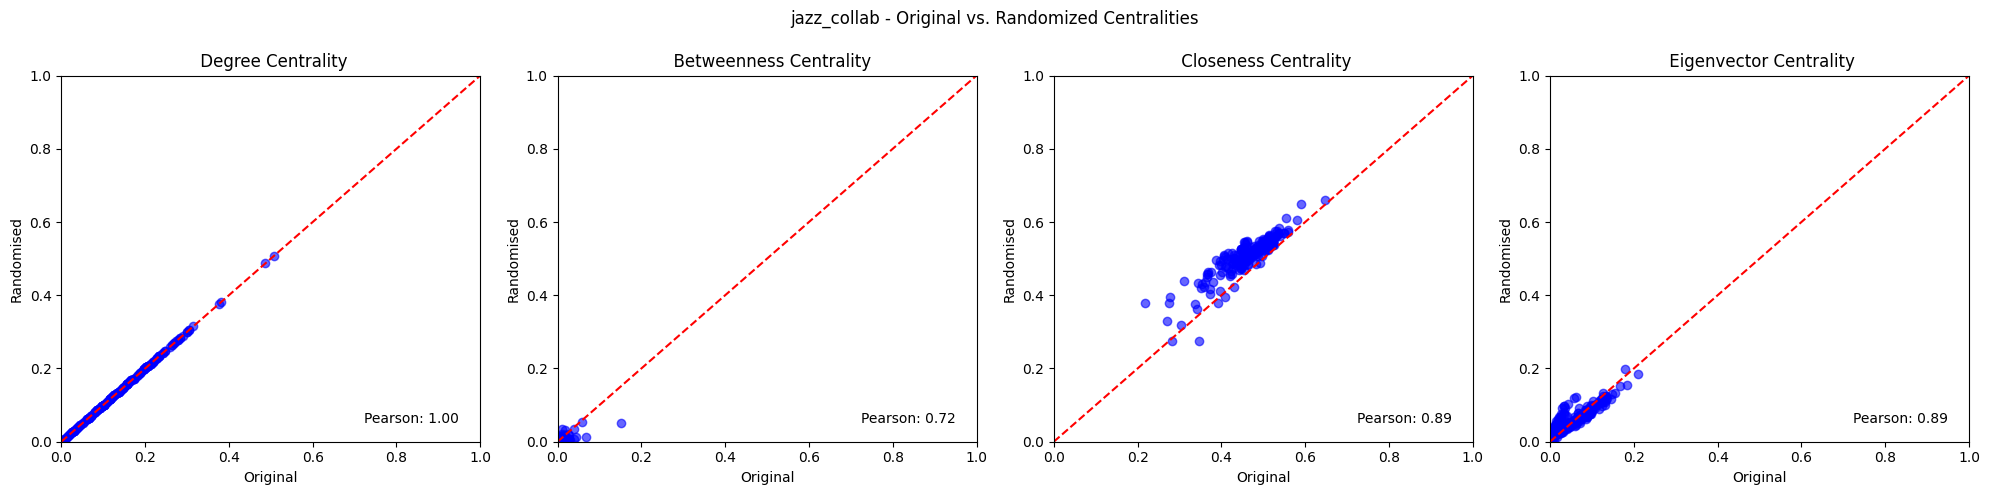

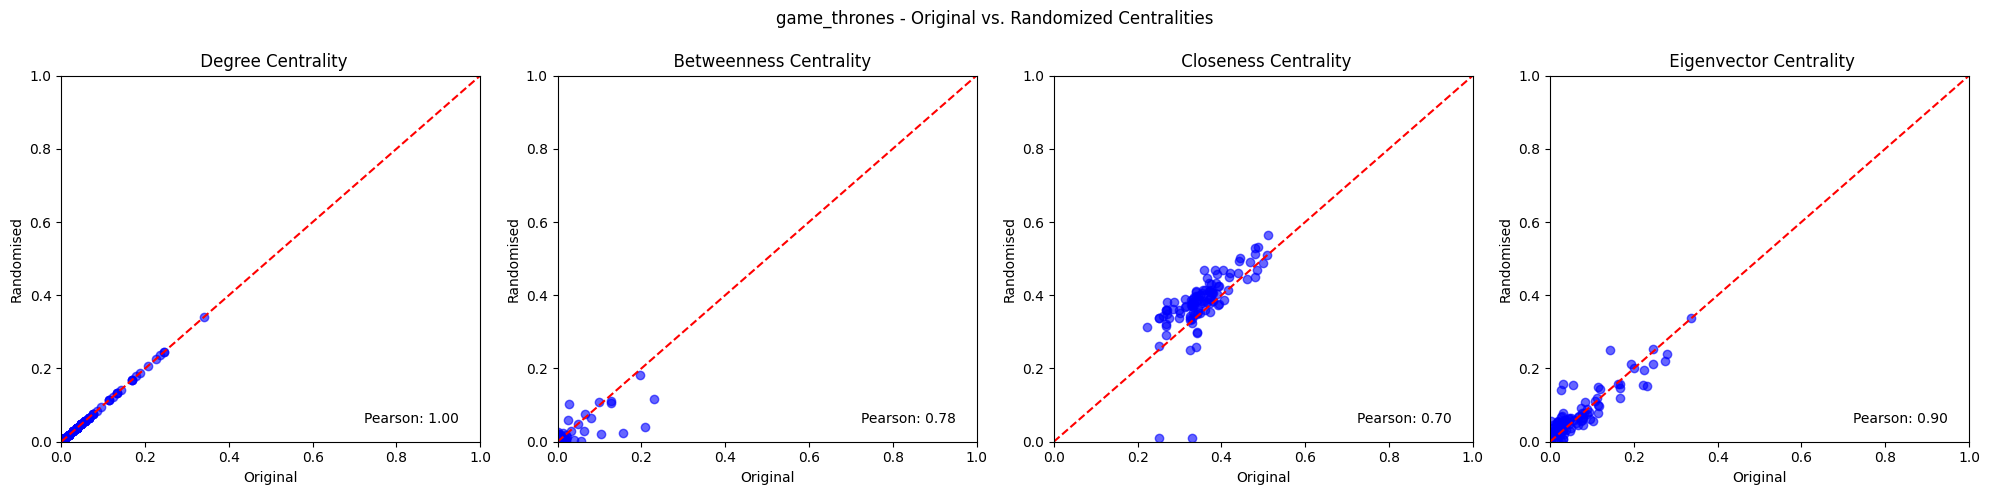

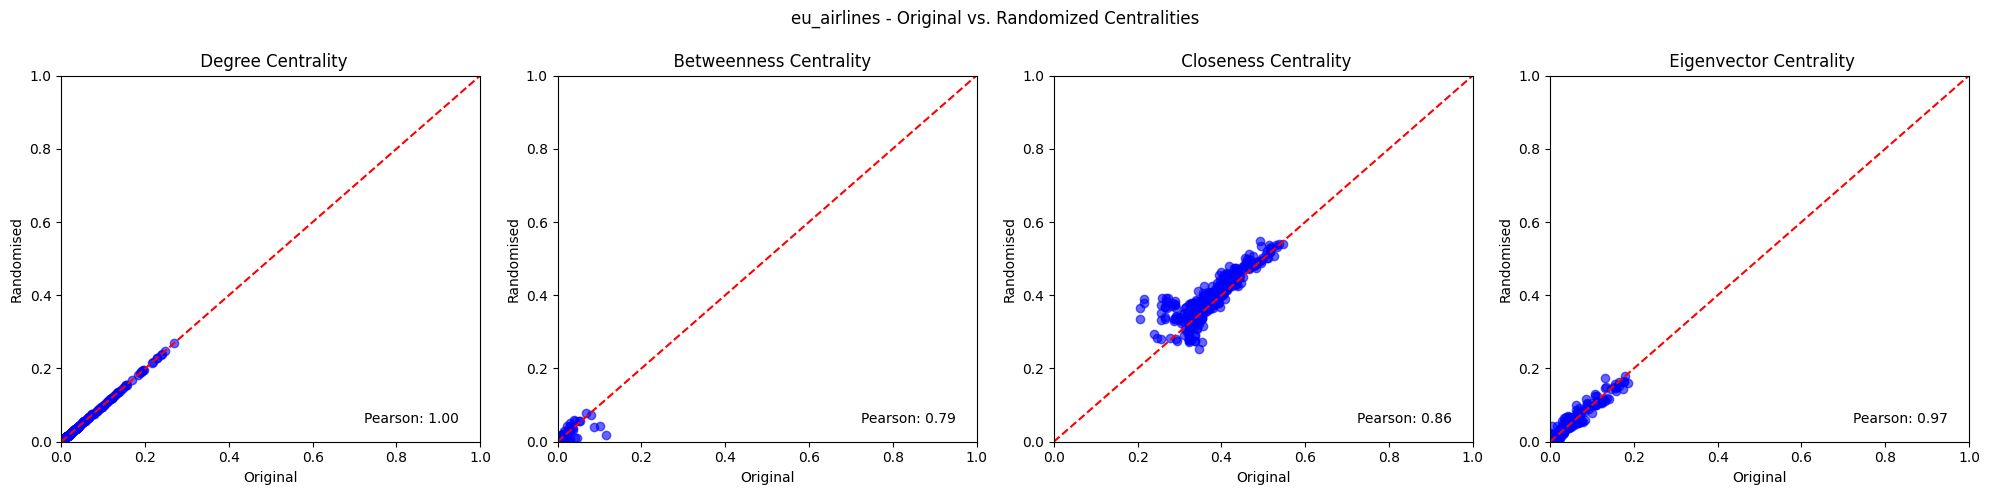

In [6]:
# Scatter plot per pair
def scatter_with_correlations(x, y, xlabel, ylabel, title, ax):
    ax.scatter(x, y, alpha=0.6, color="b")
    set_ax_labels(ax, xlabel, ylabel, title)
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)

    # Plot the diagonal line (y = x)
    ax.plot([0, 1], [0, 1], color='red', linestyle='--')

    # coefficients
    pearson_corr, _ = pearsonr(x, y)

    # Annotate figure with annoation
    ax.annotate(f'Pearson: {pearson_corr:.2f}', xy=(0.95, 0.05), xycoords='axes fraction', fontsize=10, horizontalalignment='right')

def plot_centrality_correlations(G, name):
    degree, betweenness, closeness, eigenvector = compute_centralities(G)
    RG = nx.algorithms.smallworld.random_reference(G, connectivity=False)
    degree_r, betweenness_r, closeness_r, eigenvector_r = compute_centralities(RG)

    fig, axes = initialize_figure(4,1)
 
    # correlation pair + axis labels + title
    centrality_pairs = [
        (degree, degree_r, 'Original', 'Randomised', 'Degree Centrality'),
        (betweenness, betweenness_r, 'Original', 'Randomised', ' Betweenness Centrality'),
        (closeness, closeness_r, 'Original', 'Randomised', 'Closeness Centrality'),
        (eigenvector, eigenvector_r, 'Original', 'Randomised', 'Eigenvector Centrality'),
    ]

    for ax, (x, y, xlabel, ylabel, title) in zip(axes, centrality_pairs):
        scatter_with_correlations(x, y, xlabel, ylabel, title, ax)

    fig.suptitle(f"{name} - Original vs. Randomized Centralities")
    plt.tight_layout(rect=[0, 0, 1, 0.99])

for i, g in enumerate(data_lst):
    plot_centrality_correlations(g, data_names[i])

### Brief Observations Task 3

- **Degree Centrality**:
    As to be expected the degree centrality is unaffected by the chosen randomization method. Since the edge swap method leaves the degree of a node unchanged, the degree centrality remains the same. A pearson correlation coefficient of 1.0 highlights this unchanged relation, i.e. perfect linear correlation.
  
- **Betweenness Centrality**:
    All considered centralities show a strong correlation between the original and randomized graphs, as reflected by the Pearson correlation coefficients. The lowest is observed for betweenness centrality. While the positive correlation remains after randomization, the magnitudes of the centrality values differ. Notably, the randomized networks exhibit fewer outliers at the higher end, whereas all three original datasets contain several prominent outliers. This suggests that the real-world networks possess a more structured / non-random topology, where certain nodes serve as critical intermediaries or connector hubs. This shift after randomization is an indication that some real-world networks exhibit more bottleneck-like structures and are in a sense more hierarchical than their randomized counterparts.

- **Closeness Centrality**:
    The closeness centralities exhibit a strong correlation between the original and randomized graphs. This suggests that randomization mostly preserves the core structure of the networks in terms of node accessibility, though some spread is noticeable. Notably, while the magnitudes of centrality measures differ slightly, the overall network reachability remains intact. Given that closeness centrality is also a global property, like betweenness, it is somewhat again to be expected to see some shifts (altough minor) in the node importance based on closeness. Where betweenness indicated that real world networks have a stronger propensity for bottlenecks than random versions thereof, they also seem to have more 'central' sources, as a consequence of likely intentional design. 

- **Eigenvector Centrality**:
    Of the centrality measures considered in the comparison original vs. randomized (excluding the degree centrality, since it is trivial), eigenvector centrality appears to be the least affected, tough again the correlation is not perfect. However, with pearson correlation coefficients in the range of (0.91) to (0.98) the differences are almost negligible. Even in randomized networks, nodes that are connected to important nodes in terms of the eigenvector centrality retain their 'influence'. This suggests that the structural patterns of influence and importance within the networks the analyzed networks are somewhat robust to randomization, especially in the case of eu-airlines.

## Task 4

Provide an interpretation of each centrality, rooting it in the results you computed in the previous points and the real‑world relations the networks are describing. Explain the interpretation of each
centrality and the observed differences and similarities reported in the previous points.

## 3.1 Jazz Collaboration

Nodes represent jazz musicians and Edges represent collaborations in bands that performed between 1912 and 1940.

#### Degree Centrality
- The degree centrality of the jazz network follows a uniform distribution with few outliers in the upper range, indicating that most musicians had a relatively similar number of collaborations. However, a small group of musicians were significantly more connected, likely serving as key figures or central collaborators. These outliers may represent influential band leaders or prolific performers who worked with many different musicians, facilitating widespread musical collaboration.

#### Closeness Centrality
- The closeness centrality follows in contrast to the other measures no linear pattern (log-scaled). Rather it follows a "left-skewered bell-curve"-like structure. It follows that most musicians were relatively close to others in the network, but there were some musicians with significantly higher closeness, making them central figures within the network. The skewed distribution also hints at few musicians who were more peripheral, potentially collaborating within more isolated components of the network.

#### Betweenness Centrality
- The betweenness centrality exhibits the ever-present power law distribution, with few nodes acting as core intermediaries, i.e., bottlenecks. For the jazz example, this shows that certain key musicians played a pivotal role in connecting otherwise isolated parts of the jazz network. These musicians acted as "bridges," facilitating collaborations between musicians who might not have directly worked together, f.e. versatile jazz musician active in a wide range of jazz communities.

#### Eigenvector Centrality
- The eigenvector centrality distribution resembles the power law distribution, similar to the betweenness centrality. However, it is steeper, i.e., influence is more concentrated among a few key musicians. These highly influential musicians were not only well-connected but were also connected to other important figures in the network, facilitating their influence int the jazz scene at the time.


#### Degree vs Betweenness Centrality
- The relationship between degree and betweenness centrality shows a moderate positive correlation. The plots suggests that musicians with higher degrees (more direct collaborations) tend to also have higher betweenness centrality, meaning they are more likely to serve as intermediaries or "bridges" in the network. However, this relationship is likely driven by some outliers at the upper end, as it seems that the correlation only kicks in for nodes with a degree centrality of 0.4 and higher. The nodes below exhibit mostly negligible betweenness centralities.

#### Degree vs Closeness Centrality
-  The degree and closeness centrality exhibit a strong positive correlation. This suggests that musicians with more collaborations tend to be "closer" to others in the network, having shorter paths to reach all other musicians. The clustering of points around a curve rather than the diagonal implies a non-linear relationship, where closeness centrality increases rapidly for musicians with only slighlty higher degrees.

#### Degree vs Eigenvector Centrality
- The correlation between degree and eigenvector centrality is quite strong, with values of. This indicates that musicians with a higher number of direct collaborations also tend to be connected to other influential musicians. This high correlation suggests that degree centrality is a good predictor of eigenvector centrality in this network, although degree centrality grows significantly more steeply than eigenvector. This might hint towards some randomness in the connection to influential, i.e. that if a node is connected to many other nodes, it is also likely to have some influential neighbors. 

#### Betweenness vs Closeness Centrality
- The relationship between betweenness and closeness centrality is moderate and similar to betweenness and degree centrality. Only for the few nodes with the highest centrality, there appears to be a correlation to the betweenness centrality. The rest exhibits low betweenness even for high closeness (up to around 0.55).

#### Betweenness vs Eigenvector Centrality
- The correlation between betweenness and eigenvector centrality is relatively weak. This suggests that musicians who act as intermediaries are not necessarily the most connected to influential peers. The scatter of points near the origin indicates that many musicians with low betweenness also have low eigenvector centrality, while a few outliers deviate significantly from this pattern.

#### Closeness vs Eigenvector Centrality
- The closeness and eigenvector centralities show a fairly strong correlation. This implies that musicians who are "closer" to others in the network are often connected to influential musicians as well. The non-linear relationship visible in the plot shows that eigenvector centrality grows disproportionately for musicians with higher closeness, reflecting the somwehat concentrated influence of a few key musicians.

#### Randomization
- Betweenness centrality follows the pattern outlined in task 3. I.e. while the correlation between the original and the randomized version is moderately strong, the magnitude decreases with randomization. This is an indication, that while randomization preserves the bridge building properties of the nodes to some extent, their bottleneck-ness is reduced. Thus, hinting that the real world network is more componentized and connected by some core bridges that the randomized counterpart.
- Closeness and eigenvector centralities are highly correlated between the original and randomized networks, with Pearson correlations of 0.90 and 0.91, respectively. This indicates that while the randomization alters the exact structure of the network, many musicians still maintain relatively short paths to others and preserve their influence. However, the slightly less-than-perfect correlations suggest that the original network’s structure allows better access between musicians and maintains unique connections among influential peers compared to a random structure.

### Summary
- Degree centrality is a fairly good proxy for both closeness and eigenvector centrality, meaning musicians with more collaborations are typically well-connected and influential.
- Betweenness centrality, while moderately correlated with degree and closeness, shows weaker relationships with eigenvector centrality, suggesting that the role of intermediaries in this network is somewhat independent of being highly influential or well-connected. This could hint that these bride building musicians are connecting clusters of different otherwise separated components due to their musical versatility, while themselves not being very influential overall.
- The eigenvector centrality measure consistently shows steep growth, indicating a concentration of influence among a few essential musicians. Likely, these are the "cornerstone" musician in some fairly separated components, connected by non-influential intermediaries (as indicated by the betweenness centrality vs. eigenvector centrality).
- Randomization preserves these sturctures mostly, however, the roles of intermediaries are more dependent on the actual structure of the network and not just random chance. This goes to show that understanding the collaboration of jazz musicians at the time requires the analysis goes beyond the randomness of a certain network structure.


## 3.2 Game of Thrones
Game of Thrones co‑appearances: Nodes represent Game of Thrones characters and Edges represent co‑appearances of characters in the Game of Thrones series

#### Degree Centrality
- The degree centrality of the game of thrones network follows the power law with few highly connected nodes, likely the main characters.

#### Closeness Centrality
- Closeness is structured in a very centered "bell-curve" like distribution slightly left skewed. An indication that most characters are likely somewhat well-integrated into the plot, where most serve as supporting characters, with few very well connected main characters and only few likely non-relevant side characters. 

#### Betweenness Centrality
- Betweenness follows a nearly perfect power-law distribution and even has a somewhat long right tail. This indicates that there are few very important connectors (likely the main characters) that are connected to other "isolated" components. This will be analysed further below. Especially in the comparison of the eigenvector centrality vs betweenness centrality.
- Considering that around 40% of characters have a betweenness centrality of 0, goes to show how many side characters exists, likely only supporting in a minor part of the story.

#### Eigenvector Centrality
- Again following the power law, the eigenvector centrality follows what we can expect from a tv series. There the most influential characters (main characters) that are connected themselves and lead the plot. Each of these seem to have their one side-plot where they connect to less connected individuals as well.

#### Degree vs Betweenness Centrality
- Characters with high degree centrality often have high betweenness, indicating that well-connected characters are also important intermediaries. Some moderately connected characters still hold significant influence by bridging separate parts of the network.

#### Degree vs Closeness Centrality
- Characters with higher degree centrality also tend to have higher closeness centrality, suggesting that well-connected characters are also central to the narrative, able to quickly interact with others.

#### Degree vs Eigenvector Centrality
- There is a strong correlation between degree and eigenvector centrality, indicating that well-connected characters are often connected to other influential characters, driving key parts of the story.

#### Betweenness vs Closeness Centrality
- While characters with high betweenness often have high closeness centrality, the weaker correlation suggests that some characters connect different subplots (appear in various side-plots) but are not central to the overall network (key to the core story).

#### Betweenness vs Eigenvector Centrality
- A moderate correlation of betweenness and eigenvector centrality shows that some influential characters serve as important connectors, while others influence more within tighter groups or subplots. Thus we partly need to revise the hypothesis that betweenness alone is an indicator of importance within a tv series. While it makes intuitive sense, the complexity of a series like game of thrones allows for many side-plots that might not relate fully to the core storyline.

#### Closeness vs Eigenvector Centrality
- A strong correlation between closeness and eigenvector centrality shows that key influential characters tend to be centrally positioned, allowing them quick access to others and driving the main plotlines.

#### Randomization
- The correlation between the original and randomized networks for betweenness centrality is moderate. This indicates that randomization slightly diminishes the role of key characters as connectors, reducing their "bottleneck" influence. This suggests that the Game of Thrones network is more structured around crucial connectors that hold together separate components, a feature that becomes less pronounced in a randomized version.
- Closeness centrality shows a strong correlation between the original and randomized networks. This suggests that many characters still maintain relatively short paths to others even after randomization, implying that the narrative’s core structure remains relatively intact. However, the original network appears to provide better access to likely the main characters. In terms of the tv series, this implies that the plots are better connected in the original network than in a randomized counterpart.
- Eigenvector centrality retains a high Pearson correlation of 0.90 between the original and randomized versions. This suggests that the most influential characters remain dominant in terms of their influence over others, even in the randomized network. However, the slight reduction in correlation hints that the original network focuses more heavily on core characters, likely due to the intentional plot design.

### Summary
- The network is structured around a few highly connected and influential main characters, with strong correlations between degree, closeness, and eigenvector centralities.
- Betweenness centrality reveals key characters that act as connectors, though their role is diminished in a randomized version of the network.
- Randomization generally preserves closeness and eigenvector centralities, but the original network focuses more strongly on core characters, reflecting the story design of the writers. 


## 3.3 EU Airlines
European airline network: Nodes represent airlines and Edges represent airline routes among European airports,

#### Degree Centrality
- The degree centrality of the the airline network follows the power law with few highly connected hub-like airlines, and many reginal smaller carriers.

#### Closeness Centrality
- As the other networks, also the airline network exhibits the "bell-curve"-like distribution. However, it is somwhat significantly right skewed. Intuitively, this can be interpreted as intentional airline routing design, such that most airlines are either well connected (eu-wide) or they are regional carriers but connect well to larger airlines, such that more secluded airlines still have rather quick access to the eu wide network.

#### Betweenness Centrality
- The betweenness centrality is again following the power law, while being somewhat heavy around the lower ends. This is understanable from a airline network design perspective. Most airlines will connect to many others, creating a well-connected and distributed system with hardly any bottlenecks. This not only makes sense transporation wise, but reduces the risk of a critical attack on the system, since existing bridges can rather easily be compensated.
- When we consider that 28% of nodes even have a betweenness centrality of 0, it goes to show a significant part of carriers are likely only small reginal airlines, that operate only few lines.

#### Eigenvector Centrality
- A similar sturcture can be found for eigenvector centrality, as for the betweenness centrality. There is a heavy part on the lower end, that likely reflect the peripheral smallest regional carriers, that maybe connect to only some other regional airlines and only few or even one major operator(s).

#### Degree vs Betweenness Centrality
- Airlines with high degree centrality tend to have higher betweenness, but these are not necessarily critical connectors. This reflects the airline network’s design, where well-connected airlines do not function as significant bottlenecks, to enhance the robustness of the network, since the connectivity is more distributed.

#### Degree vs Closeness Centrality
- Airlines with higher degree centrality also exhibit higher closeness centrality, indicating that well-connected airlines provide quicker access to others in the network. The right-skewed distribution indicates that what are likely regional airlines connect to the EU-wide network efficiently.

#### Degree vs Eigenvector Centrality
- A strong correlation between degree and eigenvector centrality suggests that well-connected airlines are linked to other influential airlines. These hub-like airlines dominate the network and drive much of its overall connectivity.

#### Betweenness vs Closeness Centrality 
- While there is some correlation, airlines with high betweenness do not always have the shortest paths to others. This highlights that some airlines serve as important connectors without necessarily being central to the entire network. I.e. multiple well-connected eu-wide carriers operate the core routes and connect to each other. While creating a well connected network, this reduces the bottleneck risk.

#### Betweenness vs Eigenvector Centrality
- There is a moderate correlation between betweenness and eigenvector centrality. This goes again in the same direction as before, namely that while the large, important operators to connect to each other, they are only well distributed such that only little bottleneck exist.

#### Closeness vs Eigenvector Centrality
- A strong correlation exists between closeness and eigenvector centrality, indicating that the most influential airlines are centrally located in the network, enabling quick access to many others.

#### Randomization
- The betweenness centrality correlation is moderately strong (Pearson: 0.77), showing that randomization reduces the significance of some airlines as critical connectors. This hints that the real-world network is designed to avoid bottlenecks and create a more resilience, which the randomized version does not offer.
- The closeness centrality remains relatively high in the randomized network. This indicates that most airlines maintain short paths to each other, but the original network provides a better access to the broader system, reflecting intentional route design.
- The high Pearson correlation of 0.98 for eigenvector centrality shows that the most influential airlines, in terms of their connections to other key airlines, retain their influence even after randomization. This suggests that the airline network’s core structure is resilient to random changes, with major players maintaining their influence.

### Summary
- The core takeway about the EU airline network is that it is structured around a few hub-like airlines and many regional carriers, ensuring efficient connections and minimizing vulnerabilities through well distributed connectivity (see the different betweenness centrality comparisons for details).
- The pairwise comparisons show well-connected airlines provide quick access, but the design ensures multiple connectors, reducing the bottleneck risk.
- Randomization highlights that the some parts of the airline system appear non-random to ensure high connectivity and especially reduce risks by reducing the reliance on any single carrier.

